# c-GC Single-Lag Non-Markovian Analysis

This notebook mirrors the PCMCI notebook layout and computes c-GC metrics using `GcStar.compute_metrics()`.

It writes the results to `data/outputs/c-GC/singleLag-NonMarkovian/`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

PROJECT_ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'src' / 'markovianity_diagnostic').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate project root')

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from markovianity_diagnostic.core import FastGcStar as GcStar
from markovianity_diagnostic.experiments.benchmark_data import generate_trial_data

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics


In [2]:
METHOD = 'cgc'
NOISE_MODEL = 'nonmarkovian'
SCENARIO = 'singleLag-NonMarkovian'
MASTER_SEED = 42
N_VARS_RANGE = (18, 25)
LENGTH_RANGE = (3000, 6000)
N_PASTS = list(range(1, 8))
N_LAGS = 1
NUM_TRIALS = 10
N_PERM = 1000
ALPHA = 0.01
BETA = 0.001
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'outputs' / 'c-GC' / SCENARIO
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METRIC_NAMES = ['accuracy', 'precision', 'recall', 'fpr', 'balanced_accuracy', 'f1']
METRIC_LABELS = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'fpr': 'False Positive Rate',
    'balanced_accuracy': 'Balanced Accuracy',
    'f1': 'F1 Score',
}

print(f'Method: {METHOD}')
print(f'Scenario: {SCENARIO}')
print(f'Output dir: {OUTPUT_DIR}')

Method: cgc
Scenario: singleLag-NonMarkovian
Output dir: /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/data/outputs/c-GC/singleLag-NonMarkovian


In [3]:
results = []

for trial_id in tqdm(range(NUM_TRIALS), desc=f'{METHOD.upper()} samples'):
    trial = generate_trial_data(
        SCENARIO, trial_id, seed=MASTER_SEED,
        n_vars_range=N_VARS_RANGE, length_range=LENGTH_RANGE,
    )
    X, A, n_neur, length = trial.X, trial.A, trial.n_vars, trial.length
    tqdm.write(f'[trial {trial_id + 1}/{NUM_TRIALS}] {n_neur} variables, {length} timepoints')

    trial_metrics = np.zeros((len(N_PASTS), 6))
    for idx, n_past in enumerate(N_PASTS):
        tqdm.write(f'    n_past {n_past} [{idx + 1}/{len(N_PASTS)}] (rows={n_neur * (n_past + 1)}) running...')
        gcstar = GcStar(n_perm=N_PERM, n_pasts=n_past, n_lags=N_LAGS, temporal=True, method=METHOD)
        gcstar.fit(X, verbose=0)
        gcstar.get_connectivity_matrix(alpha=ALPHA, beta=BETA, simulation=True)
        gcstar.compute_confusion_matrix(A, simulation=True)
        trial_metrics[idx] = np.round(gcstar.compute_metrics(), 4)

    results.append(trial_metrics)

results_array = np.asarray(results)
rows = []
for trial_id, trial in enumerate(results_array):
    for idx, n_past in enumerate(N_PASTS):
        row = {'trial_id': trial_id, 'n_past': n_past}
        for metric_idx, metric_name in enumerate(METRIC_NAMES):
            row[metric_name] = float(trial[idx, metric_idx])
        rows.append(row)

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / 'cgc_results.csv', index=False)

aggregated = {}
for n_past in N_PASTS:
    subset = df[df['n_past'] == n_past]
    aggregated[str(n_past)] = {
        metric: {
            'mean': float(np.round(subset[metric].mean(), 4)),
            'std': float(np.round(subset[metric].std(ddof=0), 4)),
        }
        for metric in METRIC_NAMES
    }

with open(OUTPUT_DIR / 'cgc_aggregated.json', 'w', encoding='utf-8') as f:
    json.dump(aggregated, f, indent=2)

summary = {
    'method': METHOD,
    'scenario': SCENARIO,
    'notebook': 'notebooks/c-GC/c-GC-singleLag-NonMarkovian.ipynb',
    'n_trials': int(results_array.shape[0]),
    'n_pasts': N_PASTS,
}
for metric in METRIC_NAMES:
    summary[f'mean_{metric}'] = float(np.round(df[metric].mean(), 4))
    summary[f'std_{metric}'] = float(np.round(df[metric].std(ddof=0), 4))

with open(OUTPUT_DIR / 'cgc_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print(f'Wrote results to {OUTPUT_DIR}')

CGC samples:   0%|          | 0/10 [00:00<?, ?it/s]

[trial 1/10] 24 variables, 3860 timepoints
    n_past 1 [1/7] (rows=48) running...


CGC samples:   0%|          | 0/10 [00:07<?, ?it/s]

    n_past 2 [2/7] (rows=72) running...


CGC samples:   0%|          | 0/10 [00:15<?, ?it/s]

...

    n_past 6 [6/7] (rows=168) running...


CGC samples:  90%|█████████ | 9/10 [09:55<00:49, 49.72s/it]

    n_past 7 [7/7] (rows=192) running...


CGC samples: 100%|██████████| 10/10 [10:06<00:00, 60.64s/it]


Wrote results to /Users/sadiqadedayo/Documents/projects/Detecting Latent confounders with Markovianity/hidden-confounding-diagnostics/data/outputs/c-GC/singleLag-NonMarkovian


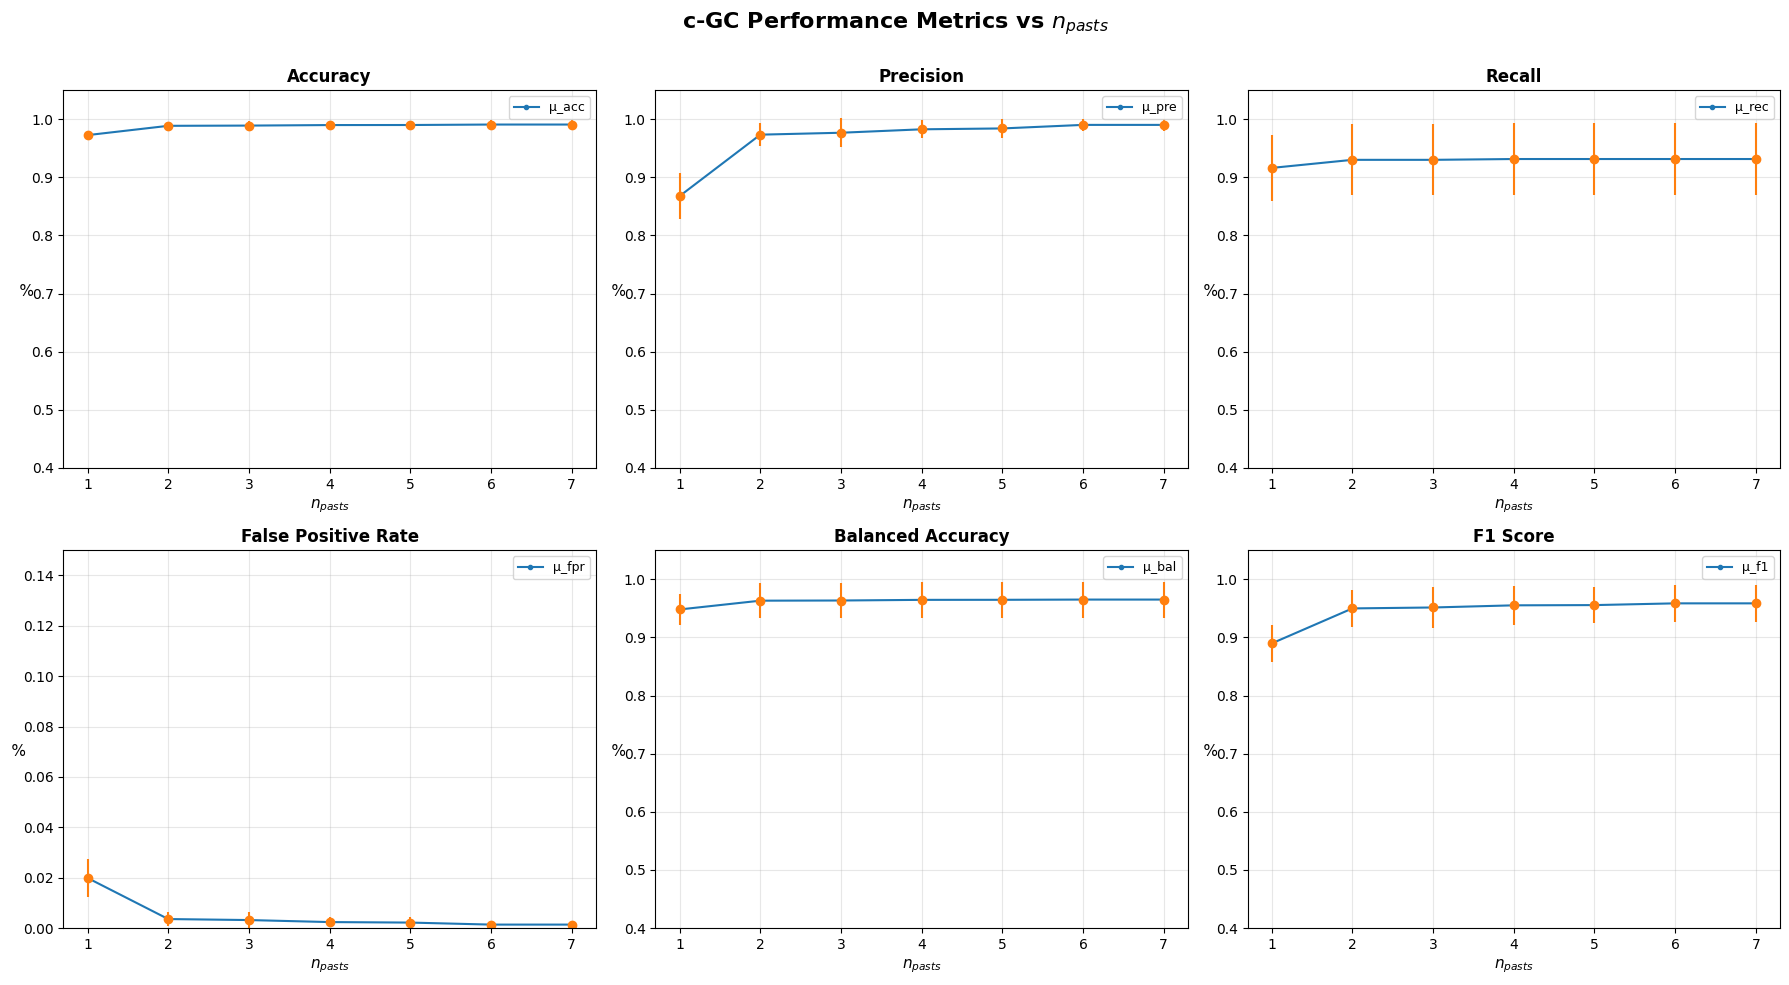

In [4]:
data_by_metric = {
    metric: {
        'mean': [aggregated[str(n_past)][metric]['mean'] for n_past in N_PASTS],
        'std': [aggregated[str(n_past)][metric]['std'] for n_past in N_PASTS],
    }
    for metric in METRIC_NAMES
}

fig, ax = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('c-GC Performance Metrics vs $n_{pasts}$', fontsize=16, fontweight='bold')
axes = ax.flatten()

for idx, metric in enumerate(METRIC_NAMES):
    axis = axes[idx]
    means = data_by_metric[metric]['mean']
    stds = data_by_metric[metric]['std']
    axis.plot(N_PASTS, means, marker='.', label=f'μ_{metric[:3]}')
    axis.errorbar(N_PASTS, means, yerr=stds, fmt='o')
    axis.set_xticks(N_PASTS)
    axis.set_xlabel('$n_{pasts}$', fontsize=11)
    axis.set_ylabel('%', fontsize=11, rotation=180)
    axis.set_title(METRIC_LABELS[metric], fontsize=12, fontweight='bold')
    axis.grid(True, alpha=0.3)
    axis.legend(fontsize=9)
    if metric == 'fpr':
        axis.set_ylim([0, 0.15])
    else:
        axis.set_ylim([0.4, 1.05])

plt.tight_layout()
fig.subplots_adjust(top=0.9)
fig.savefig(OUTPUT_DIR / 'cgc_metrics.png', dpi=300, bbox_inches='tight')
plt.show()